# Goal: produce a dataframe linking each storm report to the nearest ETC node, preserving everything needed for downstream synoptic compositing and mesoscale KDE work. 

In [4]:
### Importing necessary packages
import pandas as pd
import os
from pathlib import Path
import re
import warnings
#warnings.filterwarnings('ignore')
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as col
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import cmocean
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import numpy as np
import seaborn as sns
import xarray as xr

##Add more as needed
## custom packages
from stormevents_utils import standardize_and_convert_to_utc, build_begin_datetime, load_stormevents_data
from TE_processing import parse_nodefile, filter_tracks

### Load in storm data:

In [5]:
# Loading in the storm report data
data_dir = Path("/data1/lepique/stormevents_details/")  

df_scs = load_stormevents_data(data_dir)

## Subsetting winter months:
winter_season = {12, 1, 2,3}
df_winter_scs = df_scs[df_scs["BEGIN_DT"].dt.month.isin(winter_season)]

df_winter_scs_subset = df_winter_scs[df_winter_scs["WINTER_SEASON"] >= 1996]

Found 76 files
Reading StormEvents_details-ftp_v1.0_d1950_c20250520.csv.gz (year=1950)
Reading StormEvents_details-ftp_v1.0_d1951_c20250520.csv.gz (year=1951)
Reading StormEvents_details-ftp_v1.0_d1952_c20250520.csv.gz (year=1952)
Reading StormEvents_details-ftp_v1.0_d1953_c20250520.csv.gz (year=1953)
Reading StormEvents_details-ftp_v1.0_d1954_c20250520.csv.gz (year=1954)
Reading StormEvents_details-ftp_v1.0_d1955_c20250520.csv.gz (year=1955)
Reading StormEvents_details-ftp_v1.0_d1956_c20250520.csv.gz (year=1956)
Reading StormEvents_details-ftp_v1.0_d1957_c20250520.csv.gz (year=1957)
Reading StormEvents_details-ftp_v1.0_d1958_c20250520.csv.gz (year=1958)
Reading StormEvents_details-ftp_v1.0_d1959_c20250520.csv.gz (year=1959)
Reading StormEvents_details-ftp_v1.0_d1960_c20250520.csv.gz (year=1960)
Reading StormEvents_details-ftp_v1.0_d1961_c20250520.csv.gz (year=1961)
Reading StormEvents_details-ftp_v1.0_d1962_c20250520.csv.gz (year=1962)
Reading StormEvents_details-ftp_v1.0_d1963_c20250

In [25]:
np.unique(df_winter_scs['EVENT_TYPE'])

array(['Hail', 'Thunderstorm Wind', 'Tornado'], dtype=object)

In [27]:
df_winter_scs_2020 = df_winter_scs[df_winter_scs["WINTER_SEASON"] == 2020]
df_winter_scs_2020 = df_winter_scs_2020[df_winter_scs_2020['BEGIN_DT'].dt.month.isin({1,2,3})]
# df_winter_scs_2020 = df_winter_scs_2020[
#     (
#         (df_winter_scs_2020['EVENT_TYPE'] == 'Thunderstorm Wind') & 
#         (df_winter_scs_2020['MAGNITUDE'] >= 65)
#     )
#     |
#     (
#         (df_winter_scs_2020['EVENT_TYPE'] == 'Hail') & 
#         (df_winter_scs_2020['MAGNITUDE'] >= 2.0)
#     )
#     |
#     (
#         (df_winter_scs_2020['EVENT_TYPE'] == 'Tornado') & 
#         (df_winter_scs_2020['MAGNITUDE'] >= 2)
#     )
# ]

### Load in track data

In [5]:
## Loading in the ETC track data:
#tracks = parse_nodefile('/data1/lepique/era5_test/tracks_hourly_2020_5.txt')
tracks = parse_nodefile('/data1/lepique/era5_test/trajsens2.ERA5.hourly_kiefer.txt')

tracks = filter_tracks(tracks)

In [6]:
tracks = tracks[tracks['month'].isin({1,2,3})]
tracks = tracks[tracks['year'] == 2020]

In [7]:
tracks['datetime'].dt.hour.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23], dtype=int32)

## Pre-processing helpers

In [64]:
np.unique(tracks['lon'].values)

array([0.0000e+00, 2.5000e-01, 5.0000e-01, ..., 3.5925e+02, 3.5950e+02,
       3.5975e+02], shape=(1162,))

In [97]:
tracks

,track_id,lon,lat,msl,z,year,month,day,hour,datetime
1108023,8245,332.50,67.25,972.9406,0.0,2020,1,1,0,2020-01-01 00:00:00
1108024,8245,333.25,67.50,972.2656,0.0,2020,1,1,1,2020-01-01 01:00:00
1108025,8245,334.00,67.50,971.7975,0.0,2020,1,1,2,2020-01-01 02:00:00
1108026,8245,334.00,67.50,971.3462,0.0,2020,1,1,3,2020-01-01 03:00:00
1108027,8245,334.75,67.75,971.3850,0.0,2020,1,1,4,2020-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...
1117084,8320,254.75,44.50,1004.1650,0.0,2020,3,31,19,2020-03-31 19:00:00
1117085,8320,255.50,44.50,1003.3780,0.0,2020,3,31,20,2020-03-31 20:00:00
1117086,8320,256.25,44.50,1002.9580,0.0,2020,3,31,21,2020-03-31 21:00:00
1117087,8320,257.25,43.75,1003.1310,0.0,2020,3,31,22,2020-03-31 22:00:00


In [8]:
## PROCESSING TRACK DATA
def prep_tracks(tracks):
    tracks_h = tracks.copy()
    ## convert longitude to -180 to 180 to match storm reports
    tracks_h['lon'] = ((tracks['lon'] + 180) % 360) - 180

    ## rename datetime to time hour
    tracks_h = tracks_h.rename(columns={'datetime': 'time_hour'})
    tracks_h['time_hour'] = pd.to_datetime(tracks_h['time_hour']).dt.tz_localize('UTC')

    ## keep only columns we need
    tracks_h = tracks_h[['track_id','time_hour','lat','lon','msl']]

    ## Domain filter (even though there is already a filter, this'll drop individual nodes outside the domain)
    # tracks_h = tracks_h.loc[
    #     (tracks_h['lon'] >=135) & (tracks_h['lon'] <=-55) & 
    #     (tracks_h['lat'] >=20) & (tracks_h['lat'] <=70) 
    # ].copy()

    tracks_h = tracks_h.reset_index(drop=True)

    ## per track metadata
    ## Kiefer doesn't compute lifecycle metrics so this is new
    def _time_of_min_msl(sub: pd.Series) -> pd.Timestamp:
        """Return the hour at which msl is at a minimum for a given track
        """
        return tracks_h.loc[sub.index, 'time_hour'].iloc[
            tracks_h.loc[sub.index,'msl'].values.argmin()
        ]
    
    track_meta = (
        tracks_h.groupby('track_id')
        .agg(
            track_start = ('time_hour', 'min'),
            track_end = ('time_hour', 'max'),
            time_min_msl = ('time_hour', _time_of_min_msl),
            min_msl = ('msl', 'min'),
            n_steps = ('time_hour','size'),
        )
    )
    return tracks_h, track_meta

In [9]:
### PROCESSING REPORT DATA

def prep_reports(df_reports: pd.DataFrame) ->pd.DataFrame:
    """
    Clean and standardize the storm report data to enable merging with track data.
    """
    reports_h = df_reports.copy()

    ## ennsure datetime is a pd.datetime (though should be already)
    reports_h['BEGIN_DT_UTC'] = pd.to_datetime(reports_h['BEGIN_DT_UTC'])

    ## round to the nearest hour to match track data
    reports_h['time_hour'] = reports_h['BEGIN_DT_UTC'].dt.round('1h')

    ## rename lat/lon columns
    reports_h = reports_h.rename(columns={
        'BEGIN_LAT': 'report_lat',
        'BEGIN_LON': 'report_lon',
    })

    ## standardize lon to -180 to 180 (shouldn't be necessary but as a precaution)
    reports_h["report_lon"] = ((reports_h["report_lon"] + 180) % 360) - 180

    ## keep canonical columns first, carry rest
    core_cols = ['EVENT_ID','time_hour','report_lat','report_lon','EVENT_TYPE','BEGIN_DT_UTC']
    extra_cols = [c for c in reports_h.columns if c not in core_cols]
    reports_h = reports_h[core_cols + extra_cols].copy()

    ## drop reports with missing coordinates or EVENT_ID
    n_reports = len(reports_h)
    reports_h = reports_h.dropna(subset=['EVENT_ID','report_lat','report_lon'])
    n_dropped = n_reports - len(reports_h)
    if n_dropped:
        print(f'[prep_reports] Dropped {n_dropped} reports with missing ID or coords.')

    reports_h = reports_h.reset_index(drop=True)

    return reports_h

In [10]:
# Quick sanity-check helpers 
def check_prep_tracks(tracks_h: pd.DataFrame, track_meta: pd.DataFrame) -> None:
    """Print a basic QC summary for tracks_h and track_meta."""
    print("=== tracks_h ===")
    print(f"  Shape        : {tracks_h.shape}")
    print(f"  Date range   : {tracks_h.time_hour.min()} → {tracks_h.time_hour.max()}")
    print(f"  Lon range    : {tracks_h.lon.min():.2f} → {tracks_h.lon.max():.2f}  (expect [-135, -55])")
    print(f"  Lat range    : {tracks_h.lat.min():.2f} → {tracks_h.lat.max():.2f}  (expect [20, 70])")
    print(f"  Unique tracks: {tracks_h.track_id.nunique()}")
    print(f"  Nulls        : {tracks_h.isnull().sum().to_dict()}")
    print()
    print("=== track_meta ===")
    print(f"  Shape              : {track_meta.shape}")
    print(f"  Track duration (h) : median={track_meta.n_steps.median():.0f}  max={track_meta.n_steps.max()}")
    print(f"  MSL range (hPa)    : {track_meta.min_msl.min():.1f} → {track_meta.min_msl.max():.1f}")
    print()
 
 
def check_prep_reports(reports_h: pd.DataFrame) -> None:
    """Print a basic QC summary for reports_h."""
    print("=== reports_h ===")
    print(f"  Shape        : {reports_h.shape}")
    print(f"  Date range   : {reports_h.time_hour.min()} → {reports_h.time_hour.max()}")
    print(f"  Lon range    : {reports_h.report_lon.min():.2f} → {reports_h.report_lon.max():.2f}")
    print(f"  Lat range    : {reports_h.report_lat.min():.2f} → {reports_h.report_lat.max():.2f}")
    print(f"  EVENT_TYPE   : {reports_h.EVENT_TYPE.value_counts().to_dict()}")
    print(f"  Nulls        : {reports_h.isnull().sum().to_dict()}")
    print()

In [11]:
tracks_h, tracks_meta = prep_tracks(tracks)

In [13]:
tracks_h['time_hour']

0      2020-01-01 00:00:00+00:00
1      2020-01-01 01:00:00+00:00
2      2020-01-01 02:00:00+00:00
3      2020-01-01 03:00:00+00:00
4      2020-01-01 04:00:00+00:00
                  ...           
6535   2020-03-31 19:00:00+00:00
6536   2020-03-31 20:00:00+00:00
6537   2020-03-31 21:00:00+00:00
6538   2020-03-31 22:00:00+00:00
6539   2020-03-31 23:00:00+00:00
Name: time_hour, Length: 6540, dtype: datetime64[ns, UTC]

In [12]:
check_prep_tracks(tracks_h, tracks_meta)

=== tracks_h ===
  Shape        : (7319, 5)
  Date range   : 2020-01-01 00:00:00+00:00 → 2020-03-31 23:00:00+00:00
  Lon range    : -180.00 → 179.75  (expect [-135, -55])
  Lat range    : 17.50 → 83.75  (expect [20, 70])
  Unique tracks: 65
  Nulls        : {'track_id': 0, 'time_hour': 0, 'lat': 0, 'lon': 0, 'msl': 0}

=== track_meta ===
  Shape              : (65, 5)
  Track duration (h) : median=89  max=404
  MSL range (hPa)    : 929.9 → 1009.7



In [27]:
df_winter_scs_2020

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,BEGIN_DT,WINTER_SEASON,SOURCE_FILE_YEAR,BEGIN_DT_UTC
887742,202002,6,1140,202002,6,1148,145216.0,871942,NORTH CAROLINA,37.0,...,-80.5640,35.4970,-80.4540,Unusually high levels of moisture for early Fe...,NWS storm survey found the damage path of an E...,CSV,2020-02-06 11:40:00,2020,2020,2020-02-06 16:40:00+00:00
887753,202001,11,1033,202001,11,1036,208430.0,1298462,MISSISSIPPI,28.0,...,-89.3831,30.3680,-89.3600,Strong low pressure moving through the Middle ...,"A defined, narrow damage path was identified i...",CSV,2020-01-11 10:33:00,2020,2020,2020-01-11 16:33:00+00:00
887930,202002,6,1242,202002,6,1249,145578.0,875052,NORTH CAROLINA,37.0,...,-80.3361,35.3730,-80.2068,A strong upper-level trough tracked eastward a...,An EF-1 tornado with maximum wind speeds of 11...,CSV,2020-02-06 12:42:00,2020,2020,2020-02-06 17:42:00+00:00
887946,202002,6,1231,202002,6,1232,145578.0,875040,NORTH CAROLINA,37.0,...,-79.6473,35.8509,-79.6405,A strong upper-level trough tracked eastward a...,An EF-1 tornado with maximum wind speeds of 10...,CSV,2020-02-06 12:31:00,2020,2020,2020-02-06 17:31:00+00:00
887981,202002,6,1155,202002,6,1157,145216.0,871943,NORTH CAROLINA,37.0,...,-80.3510,35.5070,-80.3240,Unusually high levels of moisture for early Fe...,NWS storm survey found a weak tornado damage p...,CSV,2020-02-06 11:55:00,2020,2020,2020-02-06 16:55:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915061,202001,11,132,202001,11,150,144388.0,866988,LOUISIANA,22.0,...,-93.4463,32.5945,-93.1807,An upper level longwave trough emerged out of ...,This is the continuation of the Bossier Parish...,CSV,2020-01-11 01:32:00,2020,2020,2020-01-11 07:32:00+00:00
915148,202001,10,2321,202001,10,2322,144368.0,866536,TEXAS,48.0,...,-95.1751,31.8250,-95.1646,An upper level longwave trough emerged out of ...,"An EF-1 tornado, with estimated maximum winds ...",CSV,2020-01-10 23:21:00,2020,2020,2020-01-11 05:21:00+00:00
915149,202001,11,124,202001,11,132,144388.0,866960,LOUISIANA,22.0,...,-93.5875,32.5039,-93.4463,An upper level longwave trough emerged out of ...,A long track 40+ mile long EF-2 tornado with e...,CSV,2020-01-11 01:24:00,2020,2020,2020-01-11 07:24:00+00:00
915293,202001,10,2343,202001,10,2350,144368.0,866649,TEXAS,48.0,...,-94.8427,31.9194,-94.7755,An upper level longwave trough emerged out of ...,An EF-1 tornado with estimated maximum winds n...,CSV,2020-01-10 23:43:00,2020,2020,2020-01-11 05:43:00+00:00


In [28]:
reports_h = prep_reports(df_winter_scs_2020)

In [29]:
reports_h['time_hour']

0      2020-03-28 18:00:00+00:00
1      2020-03-28 18:00:00+00:00
2      2020-03-28 17:00:00+00:00
3      2020-03-28 17:00:00+00:00
4      2020-03-28 17:00:00+00:00
                  ...           
2770   2020-01-13 20:00:00+00:00
2771   2020-01-13 20:00:00+00:00
2772   2020-01-11 08:00:00+00:00
2773   2020-01-12 06:00:00+00:00
2774   2020-01-13 19:00:00+00:00
Name: time_hour, Length: 2775, dtype: datetime64[ns, UTC]

In [47]:
reports_h

,EVENT_ID,time_hour,report_lat,report_lon,EVENT_TYPE,BEGIN_DT_UTC,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,...,END_AZIMUTH,END_LOCATION,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,BEGIN_DT,WINTER_SEASON,SOURCE_FILE_YEAR
0,874475,2020-03-28 17:00:00+00:00,39.8200,-84.0100,Hail,2020-03-28 17:17:00+00:00,202003,28,1317,202003,...,E,FAIRBORN,39.8200,-84.0100,Scattered thunderstorms developed through the ...,NaN,CSV,2020-03-28 13:17:00,2020,2020
1,874476,2020-03-28 17:00:00+00:00,39.7900,-84.0200,Hail,2020-03-28 17:18:00+00:00,202003,28,1318,202003,...,ESE,WRIGHT VIEW,39.7900,-84.0200,Scattered thunderstorms developed through the ...,NaN,CSV,2020-03-28 13:18:00,2020,2020
2,874477,2020-03-28 17:00:00+00:00,39.8100,-83.8900,Hail,2020-03-28 17:26:00+00:00,202003,28,1326,202003,...,NW,YELLOW SPGS,39.8100,-83.8900,Scattered thunderstorms developed through the ...,NaN,CSV,2020-03-28 13:26:00,2020,2020
3,874478,2020-03-28 18:00:00+00:00,39.8500,-82.6100,Hail,2020-03-28 18:05:00+00:00,202003,28,1405,202003,...,W,BALTIMORE,39.8500,-82.6100,Scattered thunderstorms developed through the ...,NaN,CSV,2020-03-28 14:05:00,2020,2020
4,874479,2020-03-28 19:00:00+00:00,39.9900,-82.3100,Hail,2020-03-28 18:43:00+00:00,202003,28,1443,202003,...,ENE,LINNVILLE,39.9900,-82.3100,Scattered thunderstorms developed through the ...,NaN,CSV,2020-03-28 14:43:00,2020,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
618,929232,2020-03-19 21:00:00+00:00,40.9800,-95.1000,Hail,2020-03-19 20:36:00+00:00,202003,19,1536,202003,...,E,STANTON,40.9800,-95.1000,Severe thunderstorms produced mainly large hai...,A trained spotter reported golf ball sized hail.,CSV,2020-03-19 15:36:00,2020,2020
619,883038,2020-03-19 21:00:00+00:00,41.2300,-96.1100,Hail,2020-03-19 21:14:00+00:00,202003,19,1614,202003,...,NE,MILLARD,41.2300,-96.1100,Severe thunderstorms produced mainly large hai...,Public called in report of 1.25 inch hail near...,CSV,2020-03-19 16:14:00,2020,2020
620,877684,2020-03-19 20:00:00+00:00,40.8434,-95.2927,Hail,2020-03-19 20:14:00+00:00,202003,19,1514,202003,...,NNE,ESSEX,40.8434,-95.2927,Severe thunderstorms produced mainly large hai...,Trained Spotter reported 1.5 inch hail north o...,CSV,2020-03-19 15:14:00,2020,2020
621,929233,2020-03-19 21:00:00+00:00,40.9400,-94.9900,Hail,2020-03-19 20:45:00+00:00,202003,19,1545,202003,...,NE,VILLISCA,40.9400,-94.9900,Severe thunderstorms produced mainly large hai...,Emergency manager reported 2 inch hail.,CSV,2020-03-19 15:45:00,2020,2020


## Matching Step (joining reports to ETC tracks)

In [13]:
def haversine(lat1: np.ndarray | float, 
              lon1: np.ndarray | float, 
              lat2: np.ndarray | float, 
              lon2: np.ndarray | float) -> np.ndarray:
    """
    Great circle distance in km between two sets of lat lon points. 
    All inputs in decimal degreesl arrays must be broadcast-compatible.
    Uses numerically stable two-arg arctan2 form.
    NOTE: Kiefer et al. calls geopy.distance.geodesic inside a Python while look, one ETC candidate at a time.
    This version operates on entire columns at once.
    (could also use scikit learn haversine_distances)
    """
    R = 6371.0 # mean Earth radius (km)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

In [14]:
#### Merging reports and tracks

def match_reports_to_tracks(
        reports_h: pd.DataFrame,
        tracks_h: pd.DataFrame,
        max_dist_km: float = 2000.0,
        nw_dist_km: float = 500.0,
) -> pd.DataFrame:
    """
    Link each storm report to the nearest ETC node at the same hour,
    then apply the Kiefer et al. warm-sector proximity filter.

    Returns: 
    reports_tagged: pd.DataFrame
        reports_h with ETC columns appended
        Associated rows have: track_id, matched_time_hour, etc_lat,
        etc_lon, etc_msl, dist_km, rlon, rlat
        Unassociated rows have NaN for all ETC columns.
    """

    ## Step 1: Merge on time_hour
    pairs = reports_h.merge(
        tracks_h.rename(columns={'lat': 'etc_lat', 'lon': 'etc_lon', 'msl': 'etc_msl'}),
        on='time_hour',
        how='inner'
    )

    if pairs.empty:
        # no temporal overlap a all - return reports_h with NaN ETC cols.
        for col in ['track_id', 'etc_lat', 'etc_lon', 'etc_msl', 'dist_km', 'rlon', 'rlat']:
            reports_h[col] = np.nan
        return reports_h.copy()
    
    ## Step 2: compute great-circle distance for every pair
    pairs['dist_km'] = haversine(
        pairs['report_lat'].values, pairs['report_lon'].values,
        pairs['etc_lat'].values, pairs['etc_lon'].values,
    )

    ## Step 3: Quadrant offsets 
    pairs['rlon'] = pairs['report_lon'] - pairs['etc_lon']
    pairs['rlat'] = pairs['report_lat'] - pairs['etc_lat']

    ## Step 4: For each report, keep only the nearest ETC node
    nearest_idx = pairs.groupby('EVENT_ID')['dist_km'].idxmin()
    nearest = pairs.loc[nearest_idx].copy()

    ## Step 5: Apply the Kiefer et al. warm-sector proximity filter
        ## NW quadrant: rlon < 0 AND rlat > 0 -> tighter 500km cap
        ## all other quadrants: 2000km cap
    # NOTE (vs Kiefer Analysis.ipynb): Kiefer iterates over rows with 
    # for index, row in w_etc.iterrows(): ...
    #     if dist > 2000: nonassoc ...
    #     elif rx < 0 and ry > 0 and dist > 500: nonassoc ...
    #     else: assoc ...
    # This vectorized version should yield the same result but much faster.
    in_nw = (nearest['rlon'] < 0) & (nearest['rlat'] > 0)

    associated = nearest[
        (nearest['dist_km'] <= max_dist_km) & 
        ~(in_nw & (nearest['dist_km'] > nw_dist_km))
    ].copy()

    ## Step 6: - Left merge back onto reports_h

    etc_cols = associated[
        ['EVENT_ID','track_id','time_hour',
         'etc_lat','etc_lon','etc_msl',
         'dist_km','rlon','rlat']
    ].rename(columns={'time_hour': 'matched_time_hour'})

    reports_tagged = reports_h.merge(etc_cols, on='EVENT_ID',how='left')

    return reports_tagged

In [30]:
reports_tagged = match_reports_to_tracks(reports_h, tracks_h)

In [31]:
reports_tagged

,EVENT_ID,time_hour,report_lat,report_lon,EVENT_TYPE,BEGIN_DT_UTC,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,...,WINTER_SEASON,SOURCE_FILE_YEAR,track_id,matched_time_hour,etc_lat,etc_lon,etc_msl,dist_km,rlon,rlat
0,874472,2020-03-28 18:00:00+00:00,39.8700,-83.3800,Thunderstorm Wind,2020-03-28 17:32:00+00:00,202003,28,1332,202003,...,2020,2020,8316.0,2020-03-28 18:00:00+00:00,41.00,-95.75,992.6406,1053.545100,12.3700,-1.1300
1,874474,2020-03-28 18:00:00+00:00,39.9453,-82.7566,Thunderstorm Wind,2020-03-28 17:57:00+00:00,202003,28,1357,202003,...,2020,2020,8316.0,2020-03-28 18:00:00+00:00,41.00,-95.75,992.6406,1104.283251,12.9934,-1.0547
2,874475,2020-03-28 17:00:00+00:00,39.8200,-84.0100,Hail,2020-03-28 17:17:00+00:00,202003,28,1317,202003,...,2020,2020,8316.0,2020-03-28 17:00:00+00:00,40.50,-96.25,993.5888,1042.062256,12.2400,-0.6800
3,874476,2020-03-28 17:00:00+00:00,39.7900,-84.0200,Hail,2020-03-28 17:18:00+00:00,202003,28,1318,202003,...,2020,2020,8316.0,2020-03-28 17:00:00+00:00,40.50,-96.25,993.5888,1041.691817,12.2300,-0.7100
4,874477,2020-03-28 17:00:00+00:00,39.8100,-83.8900,Hail,2020-03-28 17:26:00+00:00,202003,28,1326,202003,...,2020,2020,8316.0,2020-03-28 17:00:00+00:00,40.50,-96.25,993.5888,1052.365790,12.3600,-0.6900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2770,873664,2020-01-13 20:00:00+00:00,35.2347,-78.1000,Thunderstorm Wind,2020-01-13 19:32:00+00:00,202001,13,1432,202001,...,2020,2020,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2771,873665,2020-01-13 20:00:00+00:00,35.2700,-78.0400,Thunderstorm Wind,2020-01-13 19:39:00+00:00,202001,13,1439,202001,...,2020,2020,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2772,866687,2020-01-11 08:00:00+00:00,32.8654,-92.5633,Tornado,2020-01-11 08:19:00+00:00,202001,11,219,202001,...,2020,2020,8259.0,2020-01-11 08:00:00+00:00,35.75,-91.25,1003.2460,342.673997,-1.3133,-2.8846
2773,873657,2020-01-12 06:00:00+00:00,35.7399,-78.2567,Thunderstorm Wind,2020-01-12 05:36:00+00:00,202001,12,36,202001,...,2020,2020,8259.0,2020-01-12 06:00:00+00:00,42.00,-81.00,998.8450,735.376056,2.7433,-6.2601


In [17]:
reports_tagged['EVENT_TYPE'].value_counts()

EVENT_TYPE
Thunderstorm Wind    1897
Hail                  623
Tornado               255
Name: count, dtype: int64

In [50]:
reports_tagged['track_id'].isnull().sum()

np.int64(204)

In [16]:
print(reports_tagged['track_id'].isnull().sum())
print(reports_tagged['track_id'].notnull().sum())

352
2423


In [103]:
reports_tagged

,EVENT_ID,time_hour,report_lat,report_lon,EVENT_TYPE,BEGIN_DT_UTC,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,...,WINTER_SEASON,SOURCE_FILE_YEAR,track_id,matched_time_hour,etc_lat,etc_lon,etc_msl,dist_km,rlon,rlat
0,874472,2020-03-28 18:00:00+00:00,39.8700,-83.3800,Thunderstorm Wind,2020-03-28 17:32:00+00:00,202003,28,1332,202003,...,2020,2020,8316.0,2020-03-28 18:00:00+00:00,41.00,-95.75,992.6406,1053.545100,12.3700,-1.1300
1,874474,2020-03-28 18:00:00+00:00,39.9453,-82.7566,Thunderstorm Wind,2020-03-28 17:57:00+00:00,202003,28,1357,202003,...,2020,2020,8316.0,2020-03-28 18:00:00+00:00,41.00,-95.75,992.6406,1104.283251,12.9934,-1.0547
2,874475,2020-03-28 17:00:00+00:00,39.8200,-84.0100,Hail,2020-03-28 17:17:00+00:00,202003,28,1317,202003,...,2020,2020,8316.0,2020-03-28 17:00:00+00:00,40.50,-96.25,993.5888,1042.062256,12.2400,-0.6800
3,874476,2020-03-28 17:00:00+00:00,39.7900,-84.0200,Hail,2020-03-28 17:18:00+00:00,202003,28,1318,202003,...,2020,2020,8316.0,2020-03-28 17:00:00+00:00,40.50,-96.25,993.5888,1041.691817,12.2300,-0.7100
4,874477,2020-03-28 17:00:00+00:00,39.8100,-83.8900,Hail,2020-03-28 17:26:00+00:00,202003,28,1326,202003,...,2020,2020,8316.0,2020-03-28 17:00:00+00:00,40.50,-96.25,993.5888,1052.365790,12.3600,-0.6900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2770,873664,2020-01-13 20:00:00+00:00,35.2347,-78.1000,Thunderstorm Wind,2020-01-13 19:32:00+00:00,202001,13,1432,202001,...,2020,2020,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2771,873665,2020-01-13 20:00:00+00:00,35.2700,-78.0400,Thunderstorm Wind,2020-01-13 19:39:00+00:00,202001,13,1439,202001,...,2020,2020,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2772,866687,2020-01-11 08:00:00+00:00,32.8654,-92.5633,Tornado,2020-01-11 08:19:00+00:00,202001,11,219,202001,...,2020,2020,8259.0,2020-01-11 08:00:00+00:00,35.75,-91.25,1003.2460,342.673997,-1.3133,-2.8846
2773,873657,2020-01-12 06:00:00+00:00,35.7399,-78.2567,Thunderstorm Wind,2020-01-12 05:36:00+00:00,202001,12,36,202001,...,2020,2020,8259.0,2020-01-12 06:00:00+00:00,42.00,-81.00,998.8450,735.376056,2.7433,-6.2601


In [33]:
print(reports_h['time_hour'].dtype)
print(tracks_h['time_hour'].dtype)

print(reports_h['time_hour'].iloc[0])
print(tracks_h['time_hour'].iloc[0])

datetime64[ns, UTC]
datetime64[ns, UTC]
2020-03-28 18:00:00+00:00
2020-01-02 14:00:00+00:00


In [32]:
overlap = set(reports_h['time_hour']) & set(tracks_h['time_hour'])
print(f"Overlapping hours: {len(overlap)}")
print(f"Total report hours: {reports_h['time_hour'].nunique()}")

Overlapping hours: 101
Total report hours: 103


In [37]:
# How many unique hours are in tracks_h at all?
print(f"Unique hours in tracks_h: {tracks_h['time_hour'].nunique()}")

# Which report hours have no ETC coverage?
missing_hours = set(reports_h['time_hour']) - set(tracks_h['time_hour'])
print(f"Report hours missing from tracks_h: {len(missing_hours)}")
print(sorted(missing_hours)[:10])  # look at the first few

Unique hours in tracks_h: 1246
Report hours missing from tracks_h: 157
[Timestamp('2020-01-10 14:00:00+0000', tz='UTC'), Timestamp('2020-01-10 16:00:00+0000', tz='UTC'), Timestamp('2020-01-10 17:00:00+0000', tz='UTC'), Timestamp('2020-01-10 18:00:00+0000', tz='UTC'), Timestamp('2020-01-10 20:00:00+0000', tz='UTC'), Timestamp('2020-01-10 21:00:00+0000', tz='UTC'), Timestamp('2020-01-10 22:00:00+0000', tz='UTC'), Timestamp('2020-01-10 23:00:00+0000', tz='UTC'), Timestamp('2020-01-11 00:00:00+0000', tz='UTC'), Timestamp('2020-01-11 01:00:00+0000', tz='UTC')]


In [34]:
missing_hours = set(reports_h['time_hour']) - set(tracks_h['time_hour'])
reports_no_etc = reports_h[reports_h['time_hour'].isin(missing_hours)]
reports_with_etc = reports_h[~reports_h['time_hour'].isin(missing_hours)]

print(f"Reports with no ETC at that hour: {len(reports_no_etc)}")
print(f"Reports with at least one ETC at that hour: {len(reports_with_etc)}")

Reports with no ETC at that hour: 4
Reports with at least one ETC at that hour: 251


In [37]:
def check_match(reports_tagged: pd.DataFrame,
                reports_h: pd.DataFrame) -> None:
    """
    Print a QC summary after match_reports_to_tracks to verify the merging process.
    """
    n_total = len(reports_tagged)
    n_reports = len(reports_h)

    if n_total != n_reports:
        print(f'[WARNING] Row count has changed: {n_reports} -> {n_total}.'
              'Check for duplicate EVENT_IDs in reports_h or tracks_h.')
    else:
        print(f'[OK] Row count preserved: {n_total}')

    assoc = reports_tagged.dropna(subset=['track_id'])
    unassoc = reports_tagged[reports_tagged['track_id'].isnull()]

    pct = 100 * len(assoc) / n_total if n_total else 0
    #print(f'Association rate: {len(assoc):,} / {n_total:.} ({pct:.1f}%)')
    print(f"\nAssociation rate : {len(assoc):,} / {n_total:,}  ({pct:.1f}%)")


    if not assoc.empty:
        print(f"\ndist_km (associated):")
        print(f"  median = {assoc.dist_km.median():.0f} km")
        print(f"  mean   = {assoc.dist_km.mean():.0f} km")
        print(f"  10th / 90th pct = {assoc.dist_km.quantile(.10):.0f} / "
              f"{assoc.dist_km.quantile(.90):.0f} km")
        
        def _quadrant(row):
            if row.rlon >=0 and row.rlat < 0: return "SE"
            if row.rlon >=0 and row.rlat >=0: return "NE"
            if row.rlon < 0 and row.rlat < 0: return "SW"
            else: return "NW"
        
        assoc = assoc.copy()
        assoc['quadrant'] = assoc.apply(_quadrant, axis=1)
        print(f'Quadrant breakdown (associated):')
        for q, cnt in assoc['quadrant'].value_counts().items():
            print(f' {q}: {cnt:,}. ({100*cnt/len(assoc):.1f}%)')

    if 'EVENT_TYPE' in reports_tagged.columns:
        print(f'Association rate by EVENT_TYPE:")')
        for etype, group in reports_tagged.groupby('EVENT_TYPE'):
            n_a = group['track_id'].notna().sum()
            print(f' {etype:25s}: {n_a:,} / {len(group):,} ({100*n_a/len(group):.1f}%)')

In [38]:
check_match(reports_tagged, reports_h)

[OK] Row count preserved: 2775

Association rate : 2,423 / 2,775  (87.3%)

dist_km (associated):
  median = 735 km
  mean   = 748 km
  10th / 90th pct = 143 / 1462 km
Quadrant breakdown (associated):
 SE: 1,125. (46.4%)
 SW: 874. (36.1%)
 NE: 402. (16.6%)
 NW: 22. (0.9%)
Association rate by EVENT_TYPE:")
 Hail                     : 548 / 623 (88.0%)
 Thunderstorm Wind        : 1,657 / 1,897 (87.3%)
 Tornado                  : 218 / 255 (85.5%)


In [39]:
reports_tagged.groupby('EVENT_TYPE')[['MAGNITUDE']].value_counts()

EVENT_TYPE         MAGNITUDE
Hail               1.00         259
                   0.75          68
                   1.75          63
                   1.25          56
                   0.88          48
                   1.50          44
                   0.25          22
                   2.00          22
                   2.50          13
                   2.75           8
                   2.25           5
                   3.00           5
                   0.13           3
                   0.70           2
                   0.35           1
                   0.38           1
                   0.50           1
                   1.30           1
                   4.50           1
Thunderstorm Wind  50.00        775
                   52.00        329
                   55.00        140
                   61.00        133
                   56.00         85
                   60.00         71
                   43.00         67
                   65.00         60

In [40]:
reports_tagged.groupby('EVENT_TYPE')[['MAGNITUDE']].value_counts()

EVENT_TYPE         MAGNITUDE
Hail               1.00         259
                   0.75          68
                   1.75          63
                   1.25          56
                   0.88          48
                   1.50          44
                   0.25          22
                   2.00          22
                   2.50          13
                   2.75           8
                   2.25           5
                   3.00           5
                   0.13           3
                   0.70           2
                   0.35           1
                   0.38           1
                   0.50           1
                   1.30           1
                   4.50           1
Thunderstorm Wind  50.00        775
                   52.00        329
                   55.00        140
                   61.00        133
                   56.00         85
                   60.00         71
                   43.00         67
                   65.00         60

## Add cyclone-keyed aggregation

joins per metadata (from prep_tracks -> track_meta) onto reports_tagged compoutes two lifecycle variables for each associated report:
- lifecycle_frac: 0-1 position of the report within the ETC's life
- hours_from_min_msl: signed hours relative to the ETC's peak intensity
(both are NaN for unassociated reports)

This stage has no Kiefer analogue, and supports analyzing where in an ETC's lifecycle severe weather clusters. 

In [41]:
def enrich_lifecycle(reports_tagged, track_meta):
    """
    Add lifecycle_frac and hours_from_min_msl to reports_tagged
    """

    out = reports_tagged.copy()

    # 1. Merge track_meta onto reports_tagged by track_id
    meta_cols = ['track_start','track_end','time_min_msl','min_msl','n_steps']

    out = out.merge(
        track_meta[meta_cols],
        left_on='track_id',
        right_index=True,
        how='left',
    )

    # 2. Compute lifecycle_frac and hours_from_min_msl
    track_span = (out['track_end'] - out['track_start'])
    elapsed = (out['matched_time_hour'] - out['track_start'])

    span_seconds = track_span.dt.total_seconds()
    with np.errstate(divide='ignore', invalid='ignore'):
        out['lifecycle_frac'] = np.where(
            span_seconds > 0,
            elapsed.dt.total_seconds() / span_seconds,
            np.nan,  ## single-node track (should not exist but just in case)
        )

    out['hours_from_min_msl'] = (
        (out['matched_time_hour'] - out['time_min_msl']).dt.total_seconds() / 3600.0
    )

    return out

In [42]:
def check_lifecycle(reports_tagged: pd.DataFrame) -> None:
    """Print a QC summary of the lifecycle enrichment."""
    assoc = reports_tagged.dropna(subset=["track_id"])

    print("=== lifecycle enrichment ===")
    print(f"  Associated reports: {len(assoc):,}")

    if assoc.empty:
        print("  (no associated reports to summarise)")
        return

    lf = assoc["lifecycle_frac"]
    print(f"\n  lifecycle_frac:")
    print(f"    range  : {lf.min():.3f} → {lf.max():.3f}  (expect within [0, 1])")
    print(f"    median : {lf.median():.3f}")
    n_oob = ((lf < 0) | (lf > 1)).sum()
    if n_oob:
        print(f"    [WARNING] {n_oob} reports have lifecycle_frac outside [0,1] — "
              "matched_time_hour falls outside [track_start, track_end]. "
              "Check that matched_time_hour came from the same track.")
    n_nan = lf.isna().sum()
    if n_nan:
        print(f"    [note] {n_nan} associated reports have NaN lifecycle_frac "
              "(degenerate single-node tracks).")

    hm = assoc["hours_from_min_msl"]
    print(f"\n  hours_from_min_msl:")
    print(f"    range  : {hm.min():.1f} → {hm.max():.1f} h")
    print(f"    median : {hm.median():.1f} h")
    pct_before = 100 * (hm < 0).mean()
    pct_after  = 100 * (hm > 0).mean()
    pct_at     = 100 * (hm == 0).mean()
    print(f"    before peak : {pct_before:.1f}%")
    print(f"    at peak     : {pct_at:.1f}%")
    print(f"    after peak  : {pct_after:.1f}%")

In [43]:
reports_tagged = enrich_lifecycle(reports_tagged, tracks_meta)

In [44]:
reports_tagged

,EVENT_ID,time_hour,report_lat,report_lon,EVENT_TYPE,BEGIN_DT_UTC,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,...,dist_km,rlon,rlat,track_start,track_end,time_min_msl,min_msl,n_steps,lifecycle_frac,hours_from_min_msl
0,874472,2020-03-28 18:00:00+00:00,39.8700,-83.3800,Thunderstorm Wind,2020-03-28 17:32:00+00:00,202003,28,1332,202003,...,1053.545100,12.3700,-1.1300,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137.0,0.630137,-4.0
1,874474,2020-03-28 18:00:00+00:00,39.9453,-82.7566,Thunderstorm Wind,2020-03-28 17:57:00+00:00,202003,28,1357,202003,...,1104.283251,12.9934,-1.0547,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137.0,0.630137,-4.0
2,874475,2020-03-28 17:00:00+00:00,39.8200,-84.0100,Hail,2020-03-28 17:17:00+00:00,202003,28,1317,202003,...,1042.062256,12.2400,-0.6800,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137.0,0.623288,-5.0
3,874476,2020-03-28 17:00:00+00:00,39.7900,-84.0200,Hail,2020-03-28 17:18:00+00:00,202003,28,1318,202003,...,1041.691817,12.2300,-0.7100,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137.0,0.623288,-5.0
4,874477,2020-03-28 17:00:00+00:00,39.8100,-83.8900,Hail,2020-03-28 17:26:00+00:00,202003,28,1326,202003,...,1052.365790,12.3600,-0.6900,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137.0,0.623288,-5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2770,873664,2020-01-13 20:00:00+00:00,35.2347,-78.1000,Thunderstorm Wind,2020-01-13 19:32:00+00:00,202001,13,1432,202001,...,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN
2771,873665,2020-01-13 20:00:00+00:00,35.2700,-78.0400,Thunderstorm Wind,2020-01-13 19:39:00+00:00,202001,13,1439,202001,...,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN
2772,866687,2020-01-11 08:00:00+00:00,32.8654,-92.5633,Tornado,2020-01-11 08:19:00+00:00,202001,11,219,202001,...,342.673997,-1.3133,-2.8846,2020-01-11 08:00:00+00:00,2020-01-14 13:00:00+00:00,2020-01-14 13:00:00+00:00,978.8231,77.0,0.000000,-77.0
2773,873657,2020-01-12 06:00:00+00:00,35.7399,-78.2567,Thunderstorm Wind,2020-01-12 05:36:00+00:00,202001,12,36,202001,...,735.376056,2.7433,-6.2601,2020-01-11 08:00:00+00:00,2020-01-14 13:00:00+00:00,2020-01-14 13:00:00+00:00,978.8231,77.0,0.285714,-55.0


In [45]:
check_lifecycle(reports_tagged)

=== lifecycle enrichment ===
  Associated reports: 2,423

  lifecycle_frac:
    range  : 0.000 → 1.000  (expect within [0, 1])
    median : 0.453

  hours_from_min_msl:
    range  : -165.0 → 142.0 h
    median : -27.0 h
    before peak : 79.7%
    at peak     : 0.7%
    after peak  : 19.6%


### Plot an ETC track and associated storm reports:

In [46]:
def plot_track_case(reports_tagged, track_h, track_id, track_meta=None,
                    zoom=False, savepath=None):
    """
    Plot the cyclone track and its associated storm reports.
    """

    ## subset:
    case_reports = reports_tagged[reports_tagged['track_id'] == track_id].copy()
    case_track = tracks_h[tracks_h['track_id'] == track_id].sort_values('time_hour')

    if case_track.empty:
        print(f'No track found for track_id={track_id}')
        return
    
    # projection
    proj_lcc = ccrs.LambertConformal(central_longitude=-99.0,
                                     central_latitude=35.0,
                                     standard_parallels=[35.0])
    fig = plt.figure(figsize=(14,10), dpi=150)
    ax = plt.axes(projection=proj_lcc)

    ## geography
    ax.coastlines(resolution='50m', color='black', linewidths=0.8)
    ax.add_feature(cfeature.BORDERS, linewidths=0.8, edgecolor='black')
    state_borders = cfeature.NaturalEarthFeature(
        category='cultural', name='admin_1_states_provinces_lakes',
        scale='50m', facecolor='none')
    ax.add_feature(state_borders, edgecolor='black', linewidth=0.5)

    if zoom:
        all_lons = np.concatenate([case_track['lon'].values,
                                   case_reports['report_lon'].dropna().values])
        all_lats = np.concatenate([case_track['lat'].values,
                                   case_reports['report_lat'].dropna().values])
        ax.set_extent([all_lons.min() - 4, all_lons.max() + 4,
                       all_lats.min() - 2, all_lats.max() + 3],
                      crs=ccrs.PlateCarree())
    else:
        ax.set_extent([-122.0, -72.5, 21.5, 50.0], crs=ccrs.PlateCarree())

    transform = ccrs.PlateCarree()

    # --- nodes every 6 hours ---
    case_track_6h = case_track[case_track['time_hour'].dt.hour % 6 == 0]

    ##  track line + nodes (colored by MSL)
    ax.plot(case_track['lon'], case_track['lat'],
            color='black', linewidth=2, alpha=0.8,
            transform=transform, zorder=3)

    sc = ax.scatter(case_track_6h['lon'], case_track_6h['lat'],
                    c=case_track_6h['msl'], cmap=cmocean.cm.dense_r,
                    s=70, edgecolor='black', linewidth=0.5,
                    transform=transform, zorder=4, label='ETC node (hourly)')
    cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('ETC MSL (hPa)', fontsize=12)

    ##  plot reports 
    if not case_reports.empty:
        et = case_reports['EVENT_TYPE'].str.upper().fillna('OTHER')
        is_tor = et.str.contains('TORNADO')
        is_hail = et.str.contains('HAIL')
        is_wind = et.str.contains('THUNDERSTORM WIND')

        ax.scatter(case_reports.loc[is_wind, 'report_lon'],
                   case_reports.loc[is_wind, 'report_lat'],
                   s=15, c='blue', alpha=0.7, transform=transform,
                   label='T-Storm Wind', zorder=5,
                   edgecolor='black', linewidth=0.2
                   )
        ax.scatter(case_reports.loc[is_hail, 'report_lon'],
                   case_reports.loc[is_hail, 'report_lat'],
                   s=15, c='lime', alpha=0.7, transform=transform,
                   label='Hail', zorder=6,
                    edgecolor='black', linewidth=0.2
                   )
        ax.scatter(case_reports.loc[is_tor, 'report_lon'],
                   case_reports.loc[is_tor, 'report_lat'],
                   s=40, c='red', alpha=0.7, transform=transform,
                   label='Tornado', zorder=7, marker='v',
                    edgecolor='black', linewidth=0.5, 
                   )
    ax.legend(loc='lower left', fontsize=11, framealpha=0.9)

    ## Title
    t0 = case_track['time_hour'].min().strftime('%Y-%m-%d %H:%M')
    t1 = case_track['time_hour'].max().strftime('%Y-%m-%d %H:%M')
    min_msl_val = case_track['msl'].min()
    title = (f"Track {int(track_id)} | {t0} → {t1} UTC | "
             f"min MSL {min_msl_val:.1f} hPa | "
             f"{len(case_reports)} reports")
    plt.title(title, fontsize=14, fontweight='bold', loc='left')
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

In [53]:
top_tracks = (reports_tagged.dropna(subset=['track_id'])
              .groupby('track_id').size()
              .sort_values(ascending=False)
              .head(20)
)

In [54]:
print(top_tracks)

track_id
8259.0    686
8316.0    465
8278.0    424
8299.0    149
8308.0    116
8318.0    113
8257.0    104
8282.0     86
8277.0     64
8305.0     64
8311.0     37
8313.0     28
8286.0     13
8314.0     12
8264.0      8
8297.0      6
8284.0      6
8312.0      6
8306.0      6
8289.0      4
dtype: int64


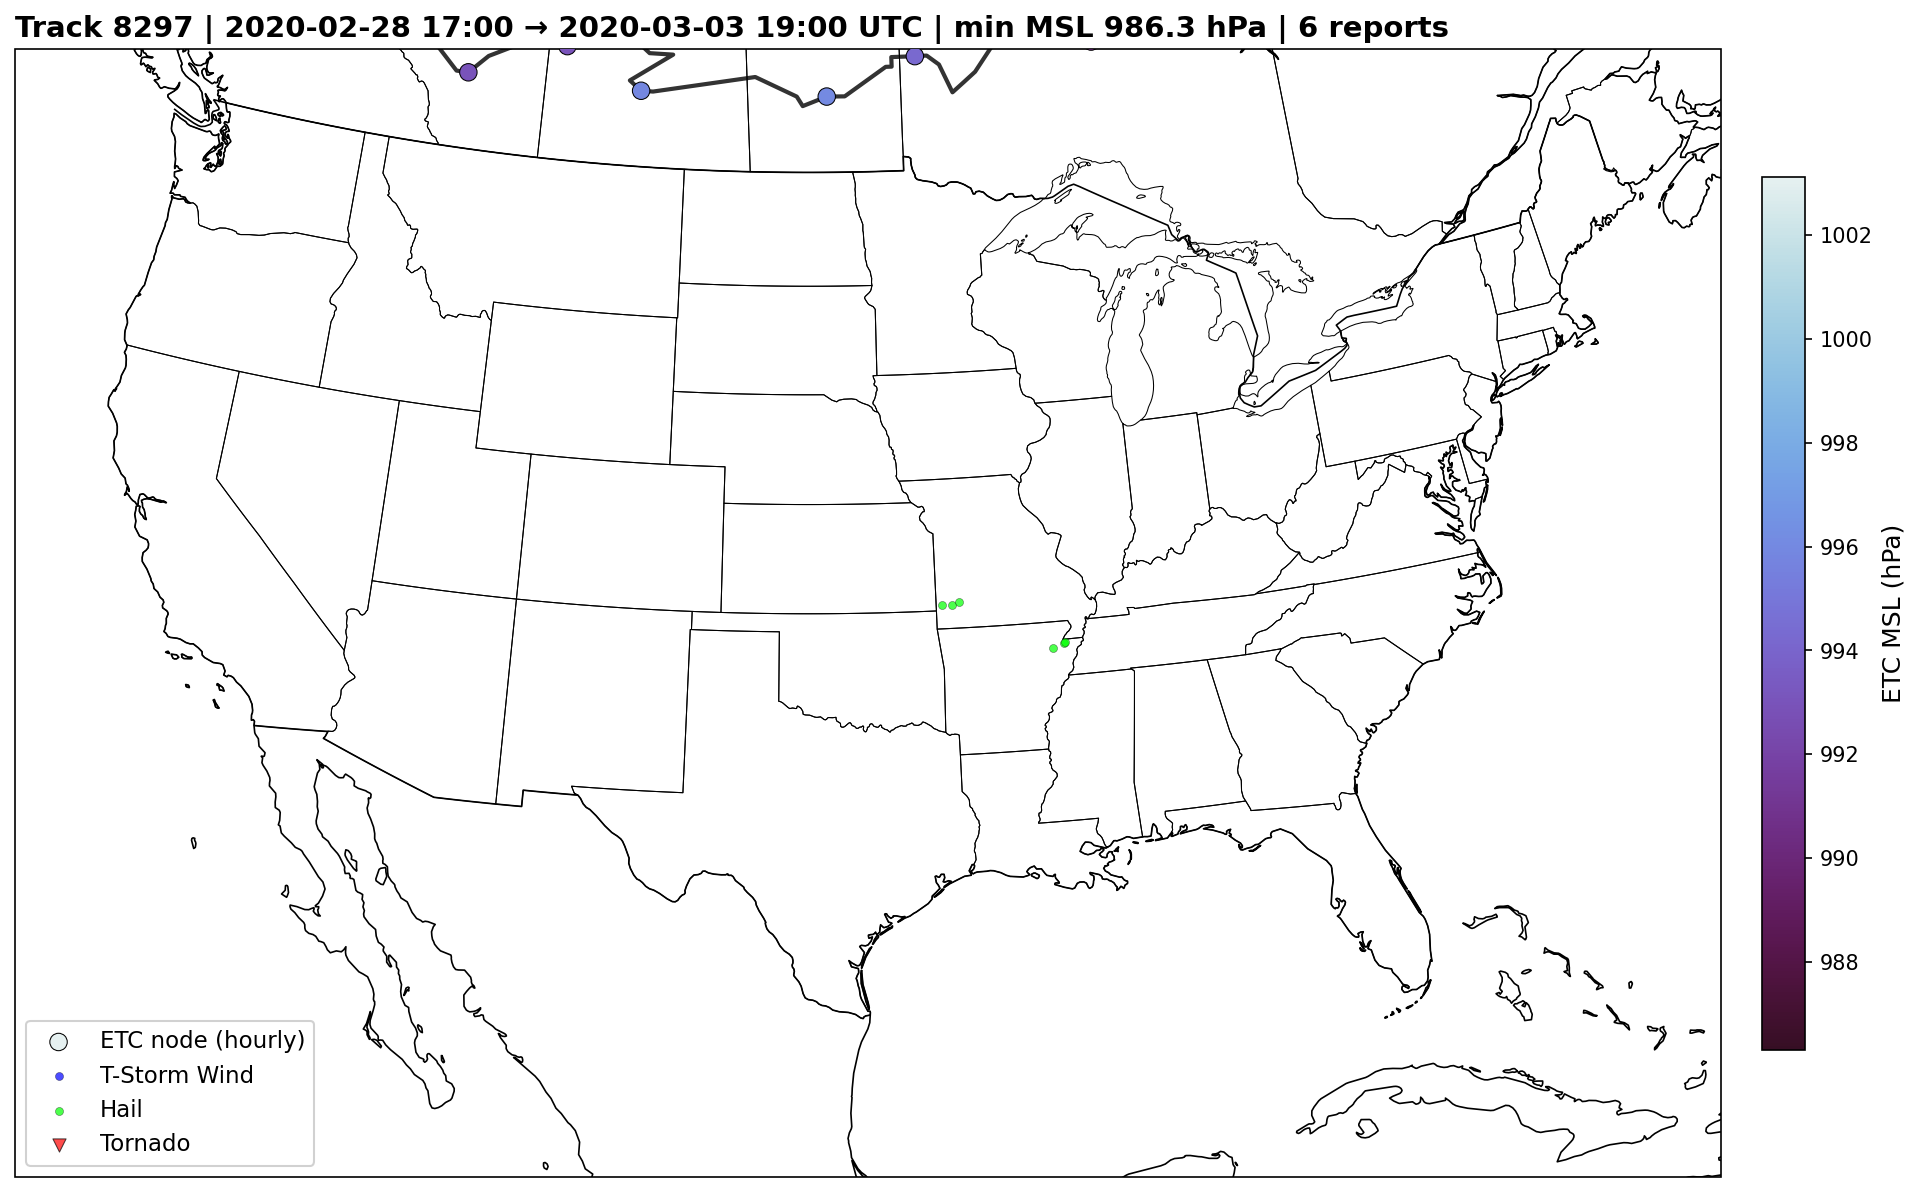

In [56]:
plot_track_case(reports_tagged, tracks_h, 8297.0, track_meta=tracks_meta)


In [29]:
tracks_meta

,track_start,track_end,time_min_msl,min_msl,n_steps
track_id,,,,,
8245,2020-01-01 00:00:00+00:00,2020-01-04 06:00:00+00:00,2020-01-03 04:00:00+00:00,946.5344,72
8246,2020-01-01 00:00:00+00:00,2020-01-01 09:00:00+00:00,2020-01-01 00:00:00+00:00,1009.1160,7
8247,2020-01-01 00:00:00+00:00,2020-01-05 22:00:00+00:00,2020-01-05 03:00:00+00:00,956.5094,115
8248,2020-01-01 11:00:00+00:00,2020-01-04 04:00:00+00:00,2020-01-01 19:00:00+00:00,986.4200,59
8249,2020-01-02 13:00:00+00:00,2020-01-06 23:00:00+00:00,2020-01-03 23:00:00+00:00,975.0175,102
...,...,...,...,...,...
8315,2020-03-23 17:00:00+00:00,2020-03-31 23:00:00+00:00,2020-03-25 19:00:00+00:00,992.0688,197
8316,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137
8318,2020-03-30 00:00:00+00:00,2020-03-31 23:00:00+00:00,2020-03-31 23:00:00+00:00,1000.3920,38


## Rollups (derived)

In [58]:
DEFAULT_EVENT_TYPES = {
    "Tornado": "tornado",
    "Hail": "hail",
    "Thunderstorm Wind": "wind",
}

In [59]:
## node-level rollup
def build_nodes_with_reports(
        reports_tagged: pd.DataFrame,
        tracks_h: pd.DataFrame,
        event_types: dict[str, str] = None,
) -> pd.DataFrame:
    """
    Attach per=node report counts to every ETC node.
    Every node in tracks_h gets a row; nodes with no reports get zeros.
    This will be used as input for TempestExtremes NodeFileFilter / NodeFileCompose.

    Returns:
    nodes_with_reports: pd.DataFrame
        One row per (track_id, time_hour) with:
            lat, lon, msl,
            n_reports, n_tornado, n_hail, n_wind 
    """

    event_types = event_types or DEFAULT_EVENT_TYPES

    assoc = reports_tagged.dropna(subset=['track_id']).copy()

    ## build aggregation dict: total count + count per event type.
    agg_kwargs = {'n_reports': ('EVENT_ID','size')}
    for label, suffix in event_types.items():
        agg_kwargs[f'n_{suffix}'] = (
            'EVENT_TYPE', lambda s, lab=label: (s == lab).sum()
        )

    node_summary = (
        assoc
        .groupby(['track_id','matched_time_hour'])
        .agg(**agg_kwargs)
        .reset_index()
        .rename(columns={'matched_time_hour': 'time_hour'})
    )

    ## left merge onto ALL nodes so nodes with no reports are retained as 0s.
    fill_cols = ['n_reports'] + [f'n_{s}' for s in event_types.values()]
    nodes_with_reports = (
        tracks_h
        .merge(node_summary, on=['track_id','time_hour'], how = 'left')
        .fillna({c: 0 for c in fill_cols})
    )

    ## counts should be integers, not floats
    for c in fill_cols:
        nodes_with_reports[c] = nodes_with_reports[c].astype(int)

    return nodes_with_reports

In [60]:
## track-level rollup
def build_etc_summary(
        reports_tagged,
        track_meta,
        event_types=None,
):
    """
    Aggregate reports to one row per ETC and join lifecycle metadata. 
    This is what we join MJO/ENSO/SPV indices onto, and what we label outbreak / non-outbreak / SCS-only / scs+snow...
    """

    event_types = event_types or DEFAULT_EVENT_TYPES

    assoc = reports_tagged.dropna(subset=['track_id']).copy()

    ## build aggregation dict: total count + count per event type.
    agg_kwargs = {'n_reports': ('EVENT_ID','size')}
    for label, suffix in event_types.items():
        agg_kwargs[f'n_{suffix}'] = (
            'EVENT_TYPE', lambda s, lab=label: (s == lab).sum()
        )

    track_summary = assoc.groupby('track_id').agg(**agg_kwargs)

    ## left join onto track_meta so EVERY track appears
    etc_summary = track_meta.join(track_summary, how='left')

    ## fill report counts with -; leave distance/timecolumns as NaN
    count_cols = ['n_reports'] + [f'n_{s}' for s in event_types.values()]
    etc_summary = etc_summary.fillna({c: 0 for c in count_cols})
    for c in count_cols:
        etc_summary[c] = etc_summary[c].astype(int)

    return etc_summary

In [61]:
nodes_with_reports = build_nodes_with_reports(reports_tagged, tracks_h)

In [62]:
nodes_with_reports

,track_id,time_hour,lat,lon,msl,n_reports,n_tornado,n_hail,n_wind
0,8245,2020-01-01 00:00:00+00:00,67.25,-27.50,972.9406,0,0,0,0
1,8245,2020-01-01 01:00:00+00:00,67.50,-26.75,972.2656,0,0,0,0
2,8245,2020-01-01 02:00:00+00:00,67.50,-26.00,971.7975,0,0,0,0
3,8245,2020-01-01 03:00:00+00:00,67.50,-26.00,971.3462,0,0,0,0
4,8245,2020-01-01 04:00:00+00:00,67.75,-25.25,971.3850,0,0,0,0
...,...,...,...,...,...,...,...,...,...
7314,8320,2020-03-31 19:00:00+00:00,44.50,-105.25,1004.1650,0,0,0,0
7315,8320,2020-03-31 20:00:00+00:00,44.50,-104.50,1003.3780,0,0,0,0
7316,8320,2020-03-31 21:00:00+00:00,44.50,-103.75,1002.9580,0,0,0,0
7317,8320,2020-03-31 22:00:00+00:00,43.75,-102.75,1003.1310,0,0,0,0


In [63]:
etc_summary = build_etc_summary(reports_tagged, tracks_meta)

In [64]:
etc_summary

,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind
track_id,,,,,,,,,
8245.0,2020-01-01 00:00:00+00:00,2020-01-04 06:00:00+00:00,2020-01-03 04:00:00+00:00,946.5344,72,0,0,0,0
8246.0,2020-01-01 00:00:00+00:00,2020-01-01 09:00:00+00:00,2020-01-01 00:00:00+00:00,1009.1160,7,0,0,0,0
8247.0,2020-01-01 00:00:00+00:00,2020-01-05 22:00:00+00:00,2020-01-05 03:00:00+00:00,956.5094,115,0,0,0,0
8248.0,2020-01-01 11:00:00+00:00,2020-01-04 04:00:00+00:00,2020-01-01 19:00:00+00:00,986.4200,59,0,0,0,0
8249.0,2020-01-02 13:00:00+00:00,2020-01-06 23:00:00+00:00,2020-01-03 23:00:00+00:00,975.0175,102,0,0,0,0
...,...,...,...,...,...,...,...,...,...
8315.0,2020-03-23 17:00:00+00:00,2020-03-31 23:00:00+00:00,2020-03-25 19:00:00+00:00,992.0688,197,0,0,0,0
8316.0,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137,465,24,266,175
8318.0,2020-03-30 00:00:00+00:00,2020-03-31 23:00:00+00:00,2020-03-31 23:00:00+00:00,1000.3920,38,113,16,0,97


In [65]:
pwd

'/home1/lepique/circs_research'

## Save outputs to CSV files:

In [ ]:
reports_tagged.to_csv('reports_tagged.csv', index=False)
nodes_with_reports.to_csv('nodes_with_reports.csv', index=False)
etc_summary.to_csv('etc_summary.csv', index=True)

In [2]:
reports_tagged = pd.read_csv('reports_tagged.csv')

In [3]:
reports_tagged

,EVENT_ID,time_hour,report_lat,report_lon,EVENT_TYPE,BEGIN_DT_UTC,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,...,dist_km,rlon,rlat,track_start,track_end,time_min_msl,min_msl,n_steps,lifecycle_frac,hours_from_min_msl
0,874472,2020-03-28 18:00:00+00:00,39.8700,-83.3800,Thunderstorm Wind,2020-03-28 17:32:00+00:00,202003,28,1332,202003,...,1053.545100,12.3700,-1.1300,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137.0,0.630137,-4.0
1,874474,2020-03-28 18:00:00+00:00,39.9453,-82.7566,Thunderstorm Wind,2020-03-28 17:57:00+00:00,202003,28,1357,202003,...,1104.283251,12.9934,-1.0547,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137.0,0.630137,-4.0
2,874475,2020-03-28 17:00:00+00:00,39.8200,-84.0100,Hail,2020-03-28 17:17:00+00:00,202003,28,1317,202003,...,1042.062256,12.2400,-0.6800,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137.0,0.623288,-5.0
3,874476,2020-03-28 17:00:00+00:00,39.7900,-84.0200,Hail,2020-03-28 17:18:00+00:00,202003,28,1318,202003,...,1041.691817,12.2300,-0.7100,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137.0,0.623288,-5.0
4,874477,2020-03-28 17:00:00+00:00,39.8100,-83.8900,Hail,2020-03-28 17:26:00+00:00,202003,28,1326,202003,...,1052.365790,12.3600,-0.6900,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137.0,0.623288,-5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2770,873664,2020-01-13 20:00:00+00:00,35.2347,-78.1000,Thunderstorm Wind,2020-01-13 19:32:00+00:00,202001,13,1432,202001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2771,873665,2020-01-13 20:00:00+00:00,35.2700,-78.0400,Thunderstorm Wind,2020-01-13 19:39:00+00:00,202001,13,1439,202001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2772,866687,2020-01-11 08:00:00+00:00,32.8654,-92.5633,Tornado,2020-01-11 08:19:00+00:00,202001,11,219,202001,...,342.673997,-1.3133,-2.8846,2020-01-11 08:00:00+00:00,2020-01-14 13:00:00+00:00,2020-01-14 13:00:00+00:00,978.8231,77.0,0.000000,-77.0
2773,873657,2020-01-12 06:00:00+00:00,35.7399,-78.2567,Thunderstorm Wind,2020-01-12 05:36:00+00:00,202001,12,36,202001,...,735.376056,2.7433,-6.2601,2020-01-11 08:00:00+00:00,2020-01-14 13:00:00+00:00,2020-01-14 13:00:00+00:00,978.8231,77.0,0.285714,-55.0
